In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "../data/Dataset Rekap.xlsx"

df = pd.read_excel(file_path, sheet_name="Item Detail")

df.head()

,No Transaksi,Tanggal,Kode Pel.,Nama Pelanggan,Kode Item,Nama Item,Jumlah,Satuan,Harga,Potongan %,Total Item,Subtotal,Pajak,Total Akhir
0,0001/JL/0125,2025-01-03,PL-0029,PT. FOKUS SAHABAT,4320-0112,"PASTEUR PIPETTE, LDPE MATERIAL, CAP.5ML/145MM ...",2,CARTON,650000.0,0.0,1300000.0,1300000.0,143000.0,1443000.0
1,0002/JL/0125,2025-01-03,PL-0001,RUMAH SAKIT YARSI,367856,"TUBE EDTA PLH 13X75, 3.0",30,BOX,276100.0,20.0,6626400.0,15021600.0,1652376.0,16673976.0
2,0002/JL/0125,2025-01-03,PL-0001,RUMAH SAKIT YARSI,367957,"TUBE SST II PLH 13X75, 3.5",30,BOX,349800.0,20.0,8395200.0,15021600.0,1652376.0,16673976.0
3,0003/JL/0125,2025-01-03,PL-0001,RUMAH SAKIT YARSI,LGN-RTA,LUNGENE COVID-19 ANTIGEN RAPID TEST,20,BOX,310000.0,0.0,6200000.0,6200000.0,682000.0,6882000.0
4,0004/JL/0125,2025-01-08,PL-0072,APOTEK MEKAR ASRI II,MK09-135,NASAL OXYGEN CANNULA ADULT,300,PCS,7500.0,30.0,1575000.0,1575000.0,173250.0,1748250.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   No Transaksi    1025 non-null   str           
 1   Tanggal         1025 non-null   datetime64[us]
 2   Kode Pel.       1025 non-null   str           
 3   Nama Pelanggan  1025 non-null   str           
 4   Kode Item       1025 non-null   str           
 5   Nama Item       1025 non-null   str           
 6   Jumlah          1025 non-null   int64         
 7   Satuan          1025 non-null   str           
 8   Harga           1025 non-null   float64       
 9   Potongan %      1025 non-null   float64       
 10  Total Item      1025 non-null   float64       
 11  Subtotal        1025 non-null   float64       
 12  Pajak           1025 non-null   float64       
 13  Total Akhir     1025 non-null   float64       
dtypes: datetime64[us](1), float64(6), int64(1), str(6)
memory usage: 18

In [3]:
df.isnull().sum()

No Transaksi      0
Tanggal           0
Kode Pel.         0
Nama Pelanggan    0
Kode Item         0
Nama Item         0
Jumlah            0
Satuan            0
Harga             0
Potongan %        0
Total Item        0
Subtotal          0
Pajak             0
Total Akhir       0
dtype: int64

In [4]:
df.describe()

,Tanggal,Jumlah,Harga,Potongan %,Total Item,Subtotal,Pajak,Total Akhir
count,1025,1025.000000,1.025000e+03,1025.000000,1.025000e+03,1.025000e+03,1.025000e+03,1.025000e+03
mean,2025-08-22 22:01:59.414634,354.127805,1.942941e+05,5.727415,2.630882e+06,2.614286e+07,2.863116e+06,2.889587e+07
min,2025-01-03 00:00:00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2025-07-01 00:00:00,3.000000,8.500000e+03,0.000000,1.653000e+05,4.343500e+06,4.777850e+05,4.821285e+06
50%,2025-08-28 00:00:00,20.000000,3.400000e+04,0.000000,7.605000e+05,1.610500e+07,1.771550e+06,1.787655e+07
75%,2025-11-13 00:00:00,150.000000,1.080000e+05,0.000000,2.940000e+06,3.921738e+07,4.313912e+06,4.353130e+07
max,2025-12-24 00:00:00,100000.000000,1.800000e+07,75.000000,6.100000e+07,1.696045e+08,1.865650e+07,1.882610e+08
std,NaN,3298.490243,1.005518e+06,12.751247,4.704952e+06,3.520388e+07,3.871393e+06,3.906270e+07


In [6]:
df["Tanggal"] = pd.to_datetime(df["Tanggal"])

df["Tahun"] = df["Tanggal"].dt.year
df["Bulan"] = df["Tanggal"].dt.month
df["Periode"] = df["Tanggal"].dt.to_period("M").astype(str)

df.head()

,No Transaksi,Tanggal,Kode Pel.,Nama Pelanggan,Kode Item,Nama Item,Jumlah,Satuan,Harga,Potongan %,Total Item,Subtotal,Pajak,Total Akhir,Tahun,Bulan,Periode
0,0001/JL/0125,2025-01-03,PL-0029,PT. FOKUS SAHABAT,4320-0112,"PASTEUR PIPETTE, LDPE MATERIAL, CAP.5ML/145MM ...",2,CARTON,650000.0,0.0,1300000.0,1300000.0,143000.0,1443000.0,2025,1,2025-01
1,0002/JL/0125,2025-01-03,PL-0001,RUMAH SAKIT YARSI,367856,"TUBE EDTA PLH 13X75, 3.0",30,BOX,276100.0,20.0,6626400.0,15021600.0,1652376.0,16673976.0,2025,1,2025-01
2,0002/JL/0125,2025-01-03,PL-0001,RUMAH SAKIT YARSI,367957,"TUBE SST II PLH 13X75, 3.5",30,BOX,349800.0,20.0,8395200.0,15021600.0,1652376.0,16673976.0,2025,1,2025-01
3,0003/JL/0125,2025-01-03,PL-0001,RUMAH SAKIT YARSI,LGN-RTA,LUNGENE COVID-19 ANTIGEN RAPID TEST,20,BOX,310000.0,0.0,6200000.0,6200000.0,682000.0,6882000.0,2025,1,2025-01
4,0004/JL/0125,2025-01-08,PL-0072,APOTEK MEKAR ASRI II,MK09-135,NASAL OXYGEN CANNULA ADULT,300,PCS,7500.0,30.0,1575000.0,1575000.0,173250.0,1748250.0,2025,1,2025-01


In [7]:
monthly_sales = df.groupby(
    ["Periode", "Kode Item", "Nama Item", "Satuan"],
    as_index=False
).agg({
    "Jumlah": "sum",
    "Total Item": "sum"
})

monthly_sales.head()

,Periode,Kode Item,Nama Item,Satuan,Jumlah,Total Item
0,2025-01,367856,"TUBE EDTA PLH 13X75, 3.0",BOX,50,11044000.0
1,2025-01,367957,"TUBE SST II PLH 13X75, 3.5",BOX,50,13992000.0
2,2025-01,4320-0112,"PASTEUR PIPETTE, LDPE MATERIAL, CAP.5ML/145MM ...",CARTON,2,1300000.0
3,2025-01,ASTAB80,ASPILET TAB 80 MG,BOX,25,2100000.0
4,2025-01,GBP300,GABAPENTIN 300 MG,BOX,50,2100000.0


In [8]:
top_items = monthly_sales.groupby(
    ["Kode Item", "Nama Item"],
    as_index=False
)["Jumlah"].sum().sort_values("Jumlah", ascending=False)

top_items.head(20)

,Kode Item,Nama Item,Jumlah
16,615,Paracetamol 500 mg Kaplet,106605
234,Guai100,Guaifenesin 100mg NOVA,26000
323,METF500,METFORMIN 500 mg Tab Bernofarm,11950
145,Clpg75,Clopidogrel 75mg Tab - Berno,11000
58,Ambtab,Ambroxol Tab Bernofarm,10052
171,Dexame,"Dexametasone 4 Pmls125 Pamol Supp 125mg 315,00...",9000
126,Cands16,Candesartan 16mg Tab,8030
127,Cands8,Candesartan 8mg Tab,7015
59,Amd,10mg Amlodipine 10mg,5551
508,Slbtm2,Salbutamol 2mg Tab (Berno),5030


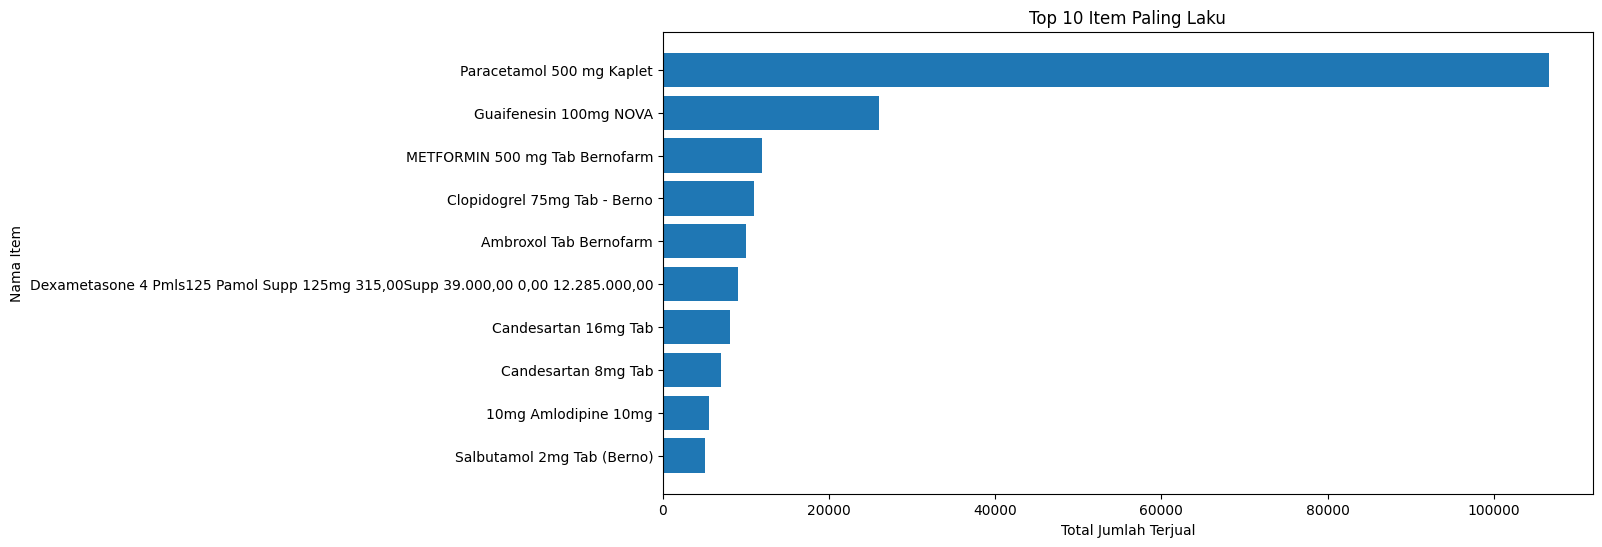

In [9]:
top_10 = top_items.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_10["Nama Item"], top_10["Jumlah"])
plt.xlabel("Total Jumlah Terjual")
plt.ylabel("Nama Item")
plt.title("Top 10 Item Paling Laku")
plt.gca().invert_yaxis()
plt.show()

In [11]:
paracetamol = monthly_sales[
    monthly_sales["Nama Item"].str.contains(
        "Paracetamol",
        case=False,
        na=False
    )
]

paracetamol

,Periode,Kode Item,Nama Item,Satuan,Jumlah,Total Item
114,2025-05,PCT-INFUS,Paracetamol 1 G/100ml Infus TD,BOX,600,13500000.00
137,2025-06,220,Paracetamol 120 mg/5 ml Syr,BTL,5,25255.00
142,2025-06,615,Paracetamol 500 mg Kaplet,BOX,4,87810.00
228,2025-07,615,Paracetamol 500 mg Kaplet,BOX,1,17568.46
229,2025-07,615,Paracetamol 500 mg Kaplet,TAB,100000,61000000.00
329,2025-07,PCT-INFUS,Paracetamol 1 G/100ml Infus TD,BOX,250,4183000.00
333,2025-07,Pct120-60,Paracetamol 120 mg/60 ml Syr Bernofarm,BTL,200,805044.00
352,2025-08,615,Paracetamol 500 mg Kaplet,TAB,6500,1677100.00
436,2025-08,PCT-INFUS,Paracetamol 1 G/100ml Infus TD,BOX,150,4148200.00
534,2025-09,PCT-INFUS,Paracetamol 1 G/100ml Infus TD,BOX,160,4312000.00


In [14]:
import sys
sys.path.append("../")

from src.forecasting import moving_average_forecast

In [16]:
item_615 = monthly_sales[monthly_sales["Kode Item"] == "615"].sort_values("Periode")

item_615

,Periode,Kode Item,Nama Item,Satuan,Jumlah,Total Item
142,2025-06,615,Paracetamol 500 mg Kaplet,BOX,4,87810.00
228,2025-07,615,Paracetamol 500 mg Kaplet,BOX,1,17568.46
229,2025-07,615,Paracetamol 500 mg Kaplet,TAB,100000,61000000.00
352,2025-08,615,Paracetamol 500 mg Kaplet,TAB,6500,1677100.00
671,2025-11,615,Paracetamol 500 mg Kaplet,TAB,100,60000.00


In [23]:
konversi = pd.read_csv("../data/konversi_satuan.csv")

konversi

,Kode Item,Nama Item,Satuan Asal,Satuan Standar,Isi Per Satuan
0,615,Paracetamol 500 mg Kaplet,BOX,TAB,100
1,615,Paracetamol 500 mg Kaplet,TAB,TAB,1


In [26]:
df["Kode Item"] = df["Kode Item"].astype(str)
konversi["Kode Item"] = konversi["Kode Item"].astype(str)

df["Nama Item"] = df["Nama Item"].astype(str).str.strip()
konversi["Nama Item"] = konversi["Nama Item"].astype(str).str.strip()

df["Satuan"] = df["Satuan"].astype(str).str.strip()
konversi["Satuan Asal"] = konversi["Satuan Asal"].astype(str).str.strip()

In [28]:
df_konversi = df.merge(
    konversi,
    left_on=["Kode Item", "Nama Item", "Satuan"],
    right_on=["Kode Item", "Nama Item", "Satuan Asal"],
    how="left"
)

df_konversi.head()

,No Transaksi,Tanggal,Kode Pel.,Nama Pelanggan,Kode Item,Nama Item,Jumlah,Satuan,Harga,Potongan %,Total Item,Subtotal,Pajak,Total Akhir,Tahun,Bulan,Periode,Satuan Asal,Satuan Standar,Isi Per Satuan
0,0001/JL/0125,2025-01-03,PL-0029,PT. FOKUS SAHABAT,4320-0112,"PASTEUR PIPETTE, LDPE MATERIAL, CAP.5ML/145MM ...",2,CARTON,650000.0,0.0,1300000.0,1300000.0,143000.0,1443000.0,2025,1,2025-01,NaN,NaN,NaN
1,0002/JL/0125,2025-01-03,PL-0001,RUMAH SAKIT YARSI,367856,"TUBE EDTA PLH 13X75, 3.0",30,BOX,276100.0,20.0,6626400.0,15021600.0,1652376.0,16673976.0,2025,1,2025-01,NaN,NaN,NaN
2,0002/JL/0125,2025-01-03,PL-0001,RUMAH SAKIT YARSI,367957,"TUBE SST II PLH 13X75, 3.5",30,BOX,349800.0,20.0,8395200.0,15021600.0,1652376.0,16673976.0,2025,1,2025-01,NaN,NaN,NaN
3,0003/JL/0125,2025-01-03,PL-0001,RUMAH SAKIT YARSI,LGN-RTA,LUNGENE COVID-19 ANTIGEN RAPID TEST,20,BOX,310000.0,0.0,6200000.0,6200000.0,682000.0,6882000.0,2025,1,2025-01,NaN,NaN,NaN
4,0004/JL/0125,2025-01-08,PL-0072,APOTEK MEKAR ASRI II,MK09-135,NASAL OXYGEN CANNULA ADULT,300,PCS,7500.0,30.0,1575000.0,1575000.0,173250.0,1748250.0,2025,1,2025-01,NaN,NaN,NaN


In [29]:
df_konversi["Isi Per Satuan"] = df_konversi["Isi Per Satuan"].fillna(1)
df_konversi["Satuan Standar"] = df_konversi["Satuan Standar"].fillna(df_konversi["Satuan"])

df_konversi["Jumlah Standar"] = (
    df_konversi["Jumlah"] * df_konversi["Isi Per Satuan"]
)

df_konversi[
    ["Kode Item", "Nama Item", "Satuan", "Jumlah", "Satuan Standar", "Isi Per Satuan", "Jumlah Standar"]
].head()

,Kode Item,Nama Item,Satuan,Jumlah,Satuan Standar,Isi Per Satuan,Jumlah Standar
0,4320-0112,"PASTEUR PIPETTE, LDPE MATERIAL, CAP.5ML/145MM ...",CARTON,2,CARTON,1.0,2.0
1,367856,"TUBE EDTA PLH 13X75, 3.0",BOX,30,BOX,1.0,30.0
2,367957,"TUBE SST II PLH 13X75, 3.5",BOX,30,BOX,1.0,30.0
3,LGN-RTA,LUNGENE COVID-19 ANTIGEN RAPID TEST,BOX,20,BOX,1.0,20.0
4,MK09-135,NASAL OXYGEN CANNULA ADULT,PCS,300,PCS,1.0,300.0


In [30]:
df_konversi[df_konversi["Kode Item"] == "615"][
    ["Kode Item", "Nama Item", "Satuan", "Jumlah", "Satuan Standar", "Isi Per Satuan", "Jumlah Standar"]
]

,Kode Item,Nama Item,Satuan,Jumlah,Satuan Standar,Isi Per Satuan,Jumlah Standar
207,615,Paracetamol 500 mg Kaplet,BOX,3,TAB,100.0,300.0
237,615,Paracetamol 500 mg Kaplet,BOX,1,TAB,100.0,100.0
299,615,Paracetamol 500 mg Kaplet,BOX,1,TAB,100.0,100.0
304,615,Paracetamol 500 mg Kaplet,TAB,100000,TAB,1.0,100000.0
441,615,Paracetamol 500 mg Kaplet,TAB,2000,TAB,1.0,2000.0
475,615,Paracetamol 500 mg Kaplet,TAB,1500,TAB,1.0,1500.0
517,615,Paracetamol 500 mg Kaplet,TAB,3000,TAB,1.0,3000.0
816,615,Paracetamol 500 mg Kaplet,TAB,100,TAB,1.0,100.0


In [31]:
monthly_sales_std = df_konversi.groupby(
    ["Periode", "Kode Item", "Nama Item", "Satuan Standar"],
    as_index=False
).agg({
    "Jumlah Standar": "sum",
    "Total Item": "sum"
})

monthly_sales_std.head()

,Periode,Kode Item,Nama Item,Satuan Standar,Jumlah Standar,Total Item
0,2025-01,367856,"TUBE EDTA PLH 13X75, 3.0",BOX,50.0,11044000.0
1,2025-01,367957,"TUBE SST II PLH 13X75, 3.5",BOX,50.0,13992000.0
2,2025-01,4320-0112,"PASTEUR PIPETTE, LDPE MATERIAL, CAP.5ML/145MM ...",CARTON,2.0,1300000.0
3,2025-01,ASTAB80,ASPILET TAB 80 MG,BOX,25.0,2100000.0
4,2025-01,GBP300,GABAPENTIN 300 MG,BOX,50.0,2100000.0


In [32]:
item_615 = monthly_sales_std[
    monthly_sales_std["Kode Item"] == "615"
].sort_values("Periode")

item_615

,Periode,Kode Item,Nama Item,Satuan Standar,Jumlah Standar,Total Item
142,2025-06,615,Paracetamol 500 mg Kaplet,TAB,400.0,87810.00
228,2025-07,615,Paracetamol 500 mg Kaplet,TAB,100100.0,61017568.46
351,2025-08,615,Paracetamol 500 mg Kaplet,TAB,6500.0,1677100.00
670,2025-11,615,Paracetamol 500 mg Kaplet,TAB,100.0,60000.00


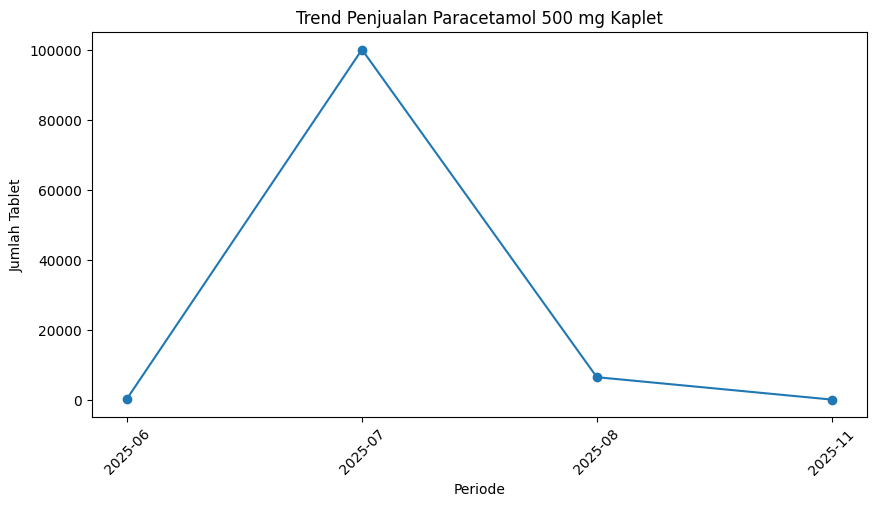

In [33]:
plt.figure(figsize=(10,5))

plt.plot(
    item_615["Periode"],
    item_615["Jumlah Standar"],
    marker="o"
)

plt.title("Trend Penjualan Paracetamol 500 mg Kaplet")
plt.xlabel("Periode")
plt.ylabel("Jumlah Tablet")
plt.xticks(rotation=45)

plt.show()

In [35]:
import importlib
import src.forecasting
importlib.reload(src.forecasting)

from src.forecasting import moving_average_forecast

In [36]:
forecast_615 = moving_average_forecast(item_615, n=3)

print("Prediksi penjualan bulan depan:", forecast_615, "tablet")

Prediksi penjualan bulan depan: 35566.67 tablet


In [37]:
ml_data = monthly_sales_std.copy()

ml_data = ml_data.sort_values(
    ["Kode Item", "Periode"]
)

ml_data.head()

,Periode,Kode Item,Nama Item,Satuan Standar,Jumlah Standar,Total Item
660,2025-11,10,CC SPUIT 10 CC,BOX,3.0,795000.0
661,2025-11,11803,Biosystem Glucose 1x50ml,BOX,1.0,825000.0
134,2025-06,1218,Miconazole Nitrate Krim 2%,BOX,1.0,108225.0
222,2025-07,1218,Miconazole Nitrate Krim 2%,TUBE,0.0,0.0
465,2025-09,1218,Miconazole Nitrate Krim 2%,BOX,1.0,136950.0


In [38]:
ml_data["Lag_1"] = ml_data.groupby(
    "Kode Item"
)["Jumlah Standar"].shift(1)

ml_data["Lag_2"] = ml_data.groupby(
    "Kode Item"
)["Jumlah Standar"].shift(2)

ml_data["Rolling_Mean_3"] = ml_data.groupby(
    "Kode Item"
)["Jumlah Standar"].transform(
    lambda x: x.rolling(3).mean()
)

ml_data.head()

,Periode,Kode Item,Nama Item,Satuan Standar,Jumlah Standar,Total Item,Lag_1,Lag_2,Rolling_Mean_3
660,2025-11,10,CC SPUIT 10 CC,BOX,3.0,795000.0,NaN,NaN,NaN
661,2025-11,11803,Biosystem Glucose 1x50ml,BOX,1.0,825000.0,NaN,NaN,NaN
134,2025-06,1218,Miconazole Nitrate Krim 2%,BOX,1.0,108225.0,NaN,NaN,NaN
222,2025-07,1218,Miconazole Nitrate Krim 2%,TUBE,0.0,0.0,1.0,NaN,NaN
465,2025-09,1218,Miconazole Nitrate Krim 2%,BOX,1.0,136950.0,0.0,1.0,0.666667


In [39]:
ml_data = ml_data.dropna()

ml_data.head()

,Periode,Kode Item,Nama Item,Satuan Standar,Jumlah Standar,Total Item,Lag_1,Lag_2,Rolling_Mean_3
465,2025-09,1218,Miconazole Nitrate Krim 2%,BOX,1.0,136950.0,0.0,1.0,0.666667
662,2025-11,1218,Miconazole Nitrate Krim 2%,TUBE,350.0,3255000.0,1.0,0.0,117.000000
347,2025-08,268,Cefadroxil Monohydrate 500mg Kapsul Bernofarm,TAB,621.0,1179900.0,1000.0,3.0,541.333333
466,2025-09,268,Cefadroxil Monohydrate 500mg Kapsul Bernofarm,BOX,30.0,2943000.0,621.0,1000.0,550.333333
664,2025-11,268,Cefadroxil Monohydrate 500mg Kapsul Bernofarm,TAB,100.0,170000.0,30.0,621.0,250.333333


In [41]:
ml_data["Periode"] = pd.to_datetime(ml_data["Periode"])

ml_data["Tahun"] = ml_data["Periode"].dt.year
ml_data["Bulan"] = ml_data["Periode"].dt.month

ml_data.head()

,Periode,Kode Item,Nama Item,Satuan Standar,Jumlah Standar,Total Item,Lag_1,Lag_2,Rolling_Mean_3,Tahun,Bulan
465,2025-09-01,1218,Miconazole Nitrate Krim 2%,BOX,1.0,136950.0,0.0,1.0,0.666667,2025,9
662,2025-11-01,1218,Miconazole Nitrate Krim 2%,TUBE,350.0,3255000.0,1.0,0.0,117.000000,2025,11
347,2025-08-01,268,Cefadroxil Monohydrate 500mg Kapsul Bernofarm,TAB,621.0,1179900.0,1000.0,3.0,541.333333,2025,8
466,2025-09-01,268,Cefadroxil Monohydrate 500mg Kapsul Bernofarm,BOX,30.0,2943000.0,621.0,1000.0,550.333333,2025,9
664,2025-11-01,268,Cefadroxil Monohydrate 500mg Kapsul Bernofarm,TAB,100.0,170000.0,30.0,621.0,250.333333,2025,11


In [42]:
features = [
    "Lag_1",
    "Lag_2",
    "Rolling_Mean_3",
    "Tahun",
    "Bulan"
]

target = "Jumlah Standar"

X = ml_data[features]
y = ml_data[target]

X.head()

,Lag_1,Lag_2,Rolling_Mean_3,Tahun,Bulan
465,0.0,1.0,0.666667,2025,9
662,1.0,0.0,117.000000,2025,11
347,1000.0,3.0,541.333333,2025,8
466,621.0,1000.0,550.333333,2025,9
664,30.0,621.0,250.333333,2025,11


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
model_dt = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

model_dt.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [46]:
y_pred = model_dt.predict(X_test)

y_pred[:10]

array([ 360.5       ,  492.31578947,  105.33333333,  105.33333333,
        360.5       ,  360.5       , 1700.        ,   19.41304348,
         49.        ,   19.41304348])

In [47]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [48]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

mape = np.mean(
    np.abs((y_test - y_pred) / y_test)
) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 220.65001634521087
RMSE: 642.166902460893
MAPE: 324.81716191238513


In [49]:
ml_data["Jumlah Standar"].describe()

count      175.000000
mean       359.137143
std       1196.636562
min          1.000000
25%         20.000000
50%         50.000000
75%        300.000000
max      10000.000000
Name: Jumlah Standar, dtype: float64

In [50]:
q1 = ml_data["Jumlah Standar"].quantile(0.25)
q3 = ml_data["Jumlah Standar"].quantile(0.75)

iqr = q3 - q1

batas_atas = q3 + (1.5 * iqr)

ml_data_clean = ml_data[
    ml_data["Jumlah Standar"] <= batas_atas
]

ml_data_clean.shape

(159, 11)

In [51]:
X = ml_data_clean[features]
y = ml_data_clean[target]

In [52]:
DecisionTreeRegressor(
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model_dt = DecisionTreeRegressor(
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model_dt.fit(X_train, y_train)

y_pred = model_dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred))
mape_dt = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("Decision Tree")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("MAPE:", mape_dt)

Decision Tree
MAE : 52.14541850693166
RMSE: 109.71103149631459
MAPE: 137.03262929466624


In [54]:
evaluasi_model = pd.DataFrame({
    "Algoritma": ["Decision Tree Regressor"],
    "MAE": [mae_dt],
    "RMSE": [rmse_dt],
    "MAPE": [mape_dt]
})

evaluasi_model

,Algoritma,MAE,RMSE,MAPE
0,Decision Tree Regressor,52.145419,109.711031,137.032629


In [55]:
ma_data = ml_data_clean.copy()

ma_data["Pred_MA"] = ma_data.groupby("Kode Item")["Jumlah Standar"].transform(
    lambda x: x.shift(1).rolling(3).mean()
)

ma_data = ma_data.dropna()

y_actual_ma = ma_data["Jumlah Standar"]
y_pred_ma = ma_data["Pred_MA"]

mae_ma = mean_absolute_error(y_actual_ma, y_pred_ma)
rmse_ma = np.sqrt(mean_squared_error(y_actual_ma, y_pred_ma))
mape_ma = np.mean(np.abs((y_actual_ma - y_pred_ma) / y_actual_ma)) * 100

print("Moving Average")
print("MAE :", mae_ma)
print("RMSE:", rmse_ma)
print("MAPE:", mape_ma)

Moving Average
MAE : 61.30496453900709
RMSE: 108.01716000613959
MAPE: 348.90138093848896


In [56]:
evaluasi_model = pd.DataFrame({
    "Algoritma": [
        "Moving Average",
        "Decision Tree Regressor"
    ],
    "MAE": [
        mae_ma,
        mae_dt
    ],
    "RMSE": [
        rmse_ma,
        rmse_dt
    ],
    "MAPE": [
        mape_ma,
        mape_dt
    ]
})

evaluasi_model

,Algoritma,MAE,RMSE,MAPE
0,Moving Average,61.304965,108.017160,348.901381
1,Decision Tree Regressor,52.145419,109.711031,137.032629


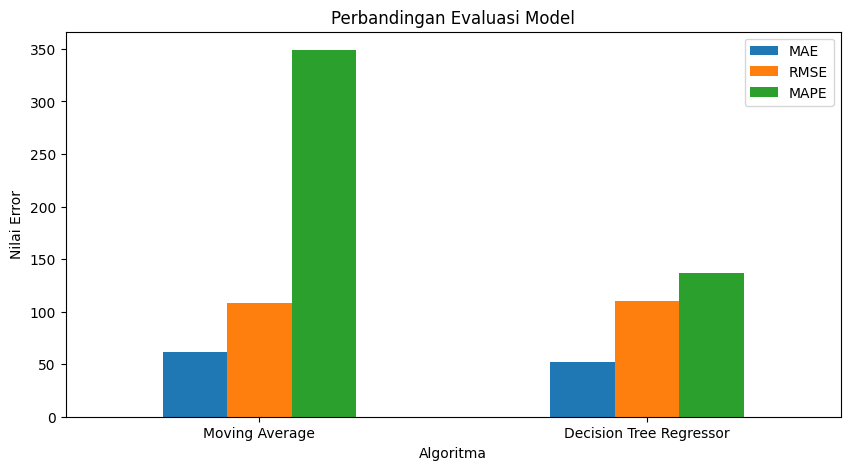

In [57]:
evaluasi_model.plot(
    x="Algoritma",
    y=["MAE", "RMSE", "MAPE"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Perbandingan Evaluasi Model")
plt.ylabel("Nilai Error")
plt.xticks(rotation=0)
plt.show()

In [59]:
forecast_results = []

for kode_item in ml_data_clean["Kode Item"].unique():
    
    item_data = ml_data_clean[
        ml_data_clean["Kode Item"] == kode_item
    ].sort_values("Periode")
    
    if len(item_data) >= 3:
        
        last_row = item_data.iloc[-1]
        
        fitur_prediksi = pd.DataFrame([{
    "Lag_1": last_row["Lag_1"],
    "Lag_2": last_row["Lag_2"],
    "Rolling_Mean_3": last_row["Rolling_Mean_3"],
    "Tahun": last_row["Tahun"],
    "Bulan": last_row["Bulan"]
}])
        
        prediksi = model_dt.predict(fitur_prediksi)[0]
        
        forecast_results.append({
            "Kode Item": last_row["Kode Item"],
            "Nama Item": last_row["Nama Item"],
            "Satuan": last_row["Satuan Standar"],
            "Penjualan Terakhir": last_row["Jumlah Standar"],
            "Prediksi Bulan Depan": round(prediksi, 2)
        })

forecast_df = pd.DataFrame(forecast_results)

forecast_df.head()

,Kode Item,Nama Item,Satuan,Penjualan Terakhir,Prediksi Bulan Depan
0,268,Cefadroxil Monohydrate 500mg Kapsul Bernofarm,BOX,2.0,45.54
1,367856,"TUBE EDTA PLH 13X75, 3.0",BOX,18.0,23.58
2,367957,"TUBE SST II PLH 13X75, 3.5",BOX,19.0,23.58
3,Amd,10mg Amlodipine 10mg,TAB,500.0,169.87
4,Aswag60,Ashwagandha+ 60 Kapsul,BTL,15.0,12.09


In [60]:
def kategori_stock(row):
    
    if row["Prediksi Bulan Depan"] > row["Penjualan Terakhir"]:
        return "Restock"
    
    elif row["Prediksi Bulan Depan"] < (row["Penjualan Terakhir"] * 0.5):
        return "Overstock"
    
    else:
        return "Aman"


forecast_df["Status Stock"] = forecast_df.apply(
    kategori_stock,
    axis=1
)

forecast_df.head()

,Kode Item,Nama Item,Satuan,Penjualan Terakhir,Prediksi Bulan Depan,Status Stock
0,268,Cefadroxil Monohydrate 500mg Kapsul Bernofarm,BOX,2.0,45.54,Restock
1,367856,"TUBE EDTA PLH 13X75, 3.0",BOX,18.0,23.58,Restock
2,367957,"TUBE SST II PLH 13X75, 3.5",BOX,19.0,23.58,Restock
3,Amd,10mg Amlodipine 10mg,TAB,500.0,169.87,Overstock
4,Aswag60,Ashwagandha+ 60 Kapsul,BTL,15.0,12.09,Aman


In [61]:
forecast_df.sort_values(
    "Prediksi Bulan Depan",
    ascending=False
).head(20)

,Kode Item,Nama Item,Satuan,Penjualan Terakhir,Prediksi Bulan Depan,Status Stock
14,OTR-S,OTORO LATEX FREE POWDER ''S'',BOX,300.0,375.74,Restock
13,OTO-M,OTORO LATEX FREE POWDER ''M'',BOX,300.0,375.74,Restock
11,Metr500,Metronidazole 500mg Tab,TAB,500.0,375.74,Aman
9,MK04-115,ELECTROSURGICAL PENCIL MK04-115,PCS,19.0,169.87,Restock
12,OTO-L,OTORO LATEX FREE POWDER ''L'',BOX,200.0,169.87,Aman
3,Amd,10mg Amlodipine 10mg,TAB,500.0,169.87,Overstock
5,IV,24G B IV CHATETER NO 24G Box @50,PCS,100.0,68.36,Aman
0,268,Cefadroxil Monohydrate 500mg Kapsul Bernofarm,BOX,2.0,45.54,Restock
10,MK08-565,MASKER MULTI ONE PLUS 3PLY EARLOOP,BOX,60.0,45.54,Aman
8,"KLP-7,5x7,5","Kassa Lipat Polos 7,5cm x 7,5cm",PAK,70.0,45.54,Aman


In [62]:
forecast_df.to_csv(
    "../model/hasil_prediksi.csv",
    index=False
)